# 1. Import Libraries
Trong phần này, chúng ta sẽ import (nhập) các thư viện thiết yếu cho việc xử lý dữ liệu, trực quan hóa và học máy bằng cách sử dụng `scikit-learn`.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

%matplotlib inline

# 2. Load Dataset
Chúng ta tải dữ liệu huấn luyện đã qua tiền xử lý từ tệp `data/processed/train_no_outlier_IQR.csv.` Dữ liệu này đã được làm sạch và lọc bỏ các giá trị ngoại lệ (outliers) bằng phương pháp Khoảng biến thiên giữa các tứ phân vị (IQR).

In [27]:
train_clean = pd.read_csv('../data/processed/train_no_outlier_IQR.csv')
print(f"Dataset shape: {train_clean.shape}")
train_clean.head()

Dataset shape: (1288, 202)


,MSSubClass,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,3,2,7,5,2003,2003,196.0,...,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,3,2,6,8,1976,1976,0.0,...,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,2,2,7,5,2001,2002,162.0,...,False,False,False,False,True,False,False,False,True,False
3,70,60.0,9550,2,2,7,5,1915,1970,0.0,...,False,False,False,False,True,False,False,False,False,False
4,60,84.0,14260,2,2,8,5,2000,2000,350.0,...,False,False,False,False,True,False,False,False,True,False


# 3. Correlation Analysis (Heatmap)
Để lựa chọn các đặc trưng (features) phù hợp nhất cho mô hình cơ sở (baseline model), chúng ta sẽ trực quan hóa ma trận tương quan. Việc này giúp xác định những biến số nào có mối quan hệ tuyến tính mạnh nhất với biến `SalePrice`.

In [29]:
numeric_df = train_clean.select_dtypes(include=[np.number])
numeric_df = numeric_df.fillna(numeric_df.mean())

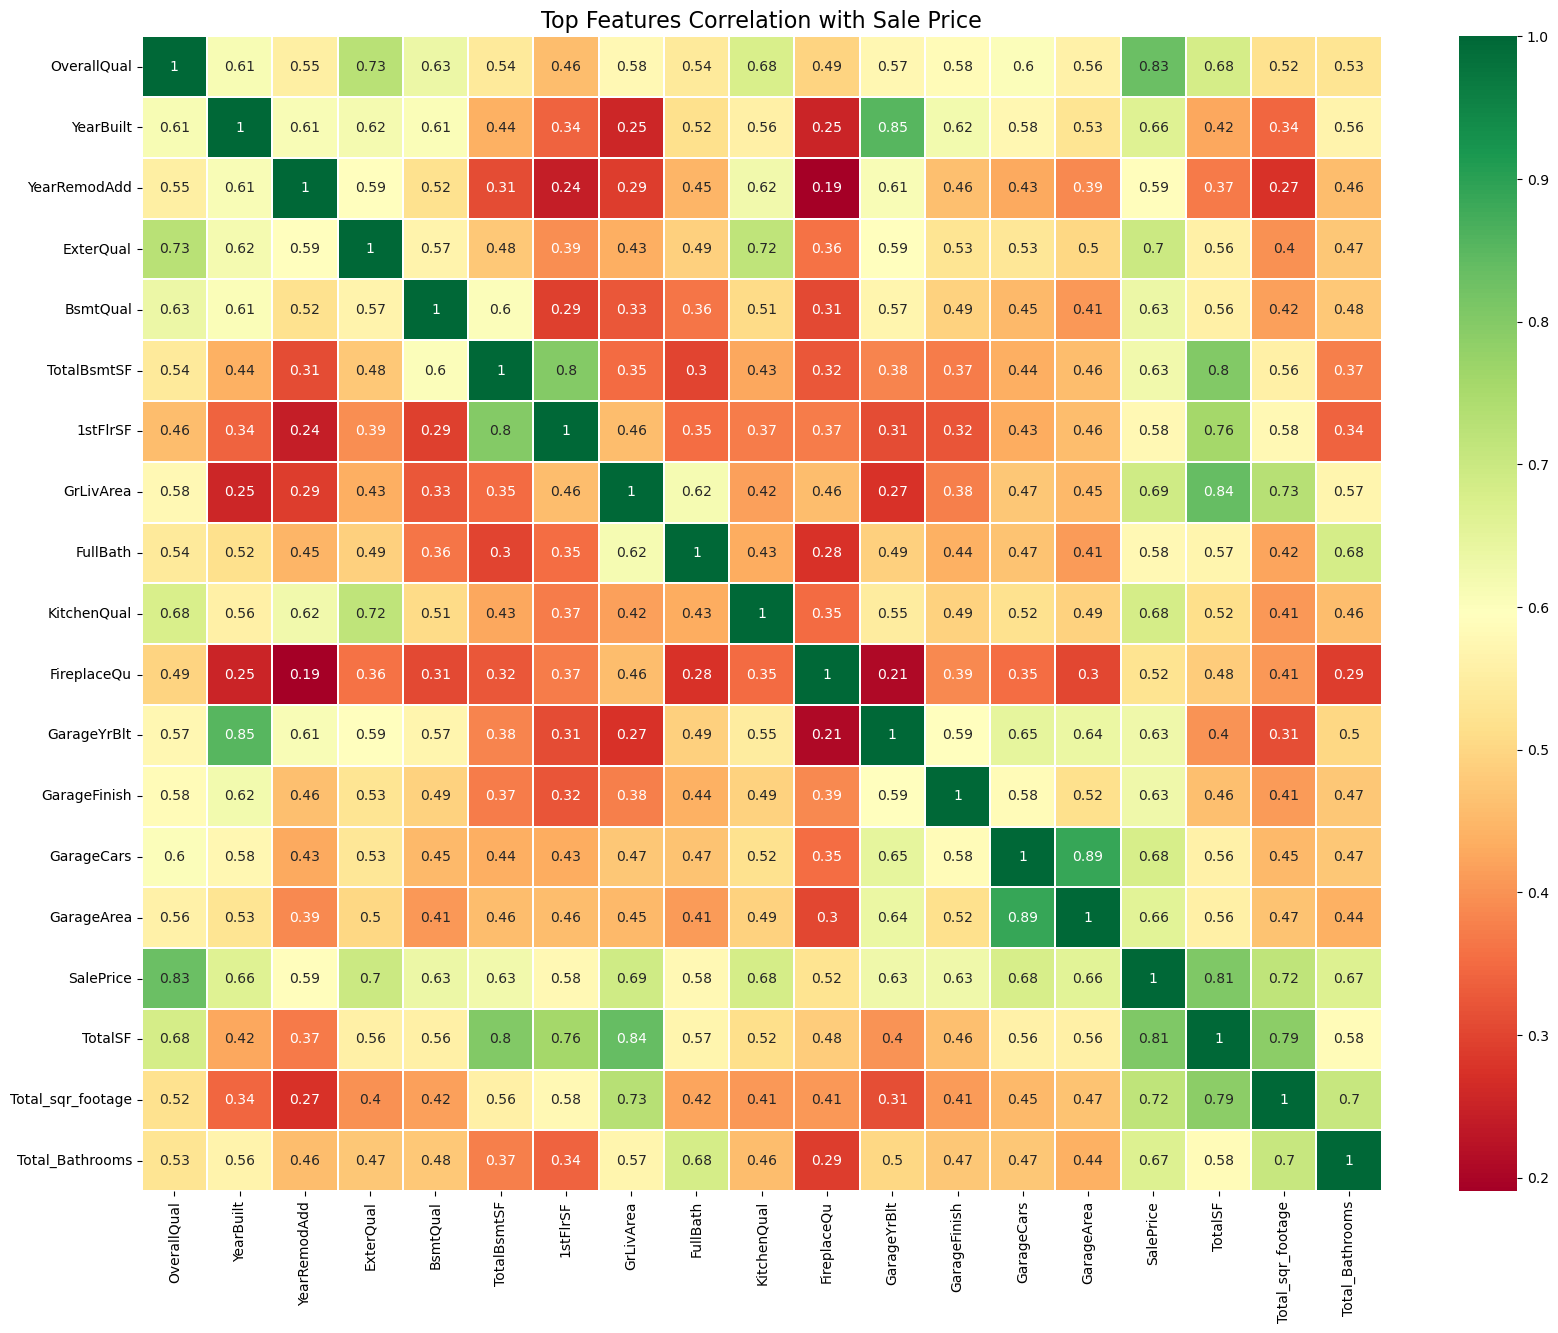

In [30]:
corr_matrix = numeric_df.corr()
top_corr_features = corr_matrix.index[abs(corr_matrix["SalePrice"]) > 0.5]

plt.figure(figsize=(20,15))
sns.heatmap(train_clean[top_corr_features].corr(), annot = True, cmap = 'RdYlGn', linewidths = 0.2)

plt.title('Top Features Correlation with Sale Price', fontsize=16)
plt.show()

# 4. Exploratory Data Analysis (EDA) - Basic Visualization
Trước khi xây dựng mô hình, chúng ta sẽ trực quan hóa mối quan hệ giữa `GrLivArea` và `SalePrice` để kiểm tra tính tuyến tính và các giá trị ngoại lệ tiềm năng.

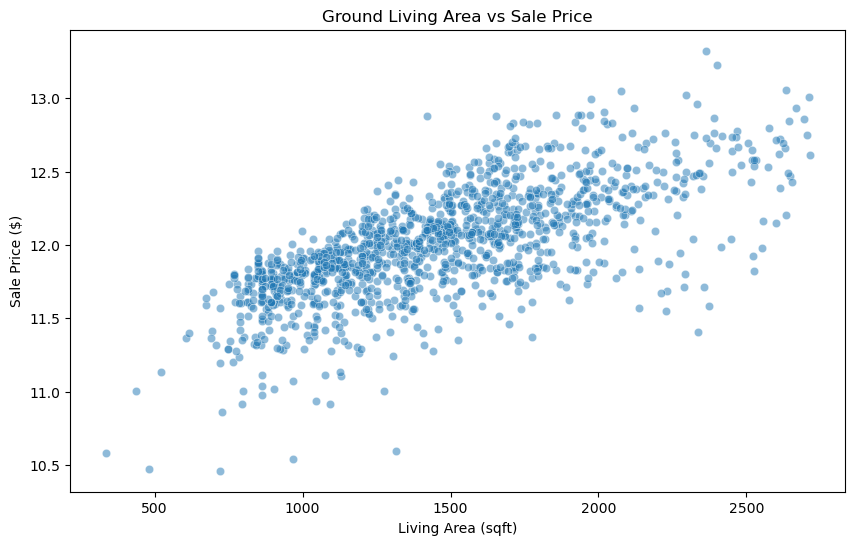

In [31]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=train_clean, x = 'GrLivArea', y = 'SalePrice', alpha = 0.5)
plt.title('Ground Living Area vs Sale Price')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Sale Price ($)')
plt.show()

# 5. Baseline Model Implementation
Dựa trên bản đồ nhiệt tương quan (correlation heatmap) và biểu đồ phân tán (scatter plot), `GrLivArea` cho thấy mối quan hệ tuyến tính mạnh mẽ với `SalePrice`. 
Giờ đây, chúng tôi sẽ xây dựng một mô hình Hồi quy Tuyến tính Đơn giản **Simple Linear Regression** bằng cách sử dụng đặc trưng duy nhất này làm mô hình cơ sở (baseline).

# 6. Train/Validation Split
Split into Training (80%) and Validation (20%) sets

In [32]:
X = train_clean[['GrLivArea']] 
y = train_clean['SalePrice']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Validation set size: {X_val.shape}")

Training set size: (1030, 1)
Validation set size: (258, 1)


# 7. Fit the Model and Compute RMSE
Khởi tạo và Huấn luyện mô hình (Fit), thực hiện dự đoán, và tính toán các chỉ số đánh giá hiệu suất.

In [33]:
baseline_reg = LinearRegression()
baseline_reg.fit(X_train, y_train)

y_pred = baseline_reg.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print(f"--- Baseline Model Results ---")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared Score: {baseline_reg.score(X_val, y_val):.4f}")

--- Baseline Model Results ---
Root Mean Squared Error (RMSE): $0.28
R-squared Score: 0.4601


In [34]:
y_val_actual = np.exp(y_val)
y_pred_actual = np.exp(y_pred)

rmse_actual = np.sqrt(mean_squared_error(y_val_actual, y_pred_actual))

print(f"--- RESULT OF BASELINE ---")
print(f"RMSE (Log Scale): {rmse:.4f}")
print(f"RMSE (Actual Price): ${rmse_actual:,.2f}")
print(f"R-squared: {baseline_reg.score(X_val, y_val):.4f}")

--- RESULT OF BASELINE ---
RMSE (Log Scale): 0.2816
RMSE (Actual Price): $53,161.01
R-squared: 0.4601


# 8. Đường Hồi quy (Regression Line)

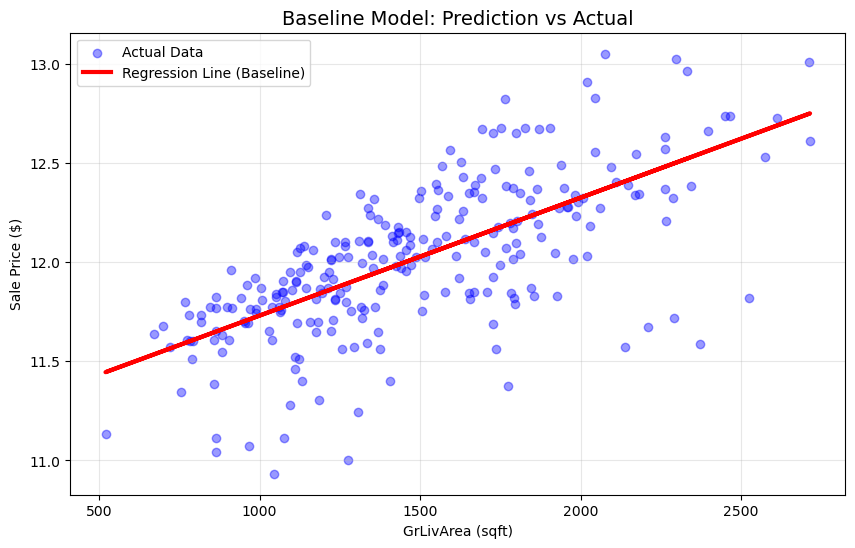

In [35]:
plt.figure(figsize=(10, 6))

plt.scatter(X_val, y_val, color='blue', alpha=0.4, label='Actual Data')

plt.plot(X_val, y_pred, color='red', linewidth=3, label='Regression Line (Baseline)')

plt.title('Baseline Model: Prediction vs Actual', fontsize=14)
plt.xlabel('GrLivArea (sqft)')
plt.ylabel('Sale Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 9. Biểu đồ Sai số (Residual Plot)

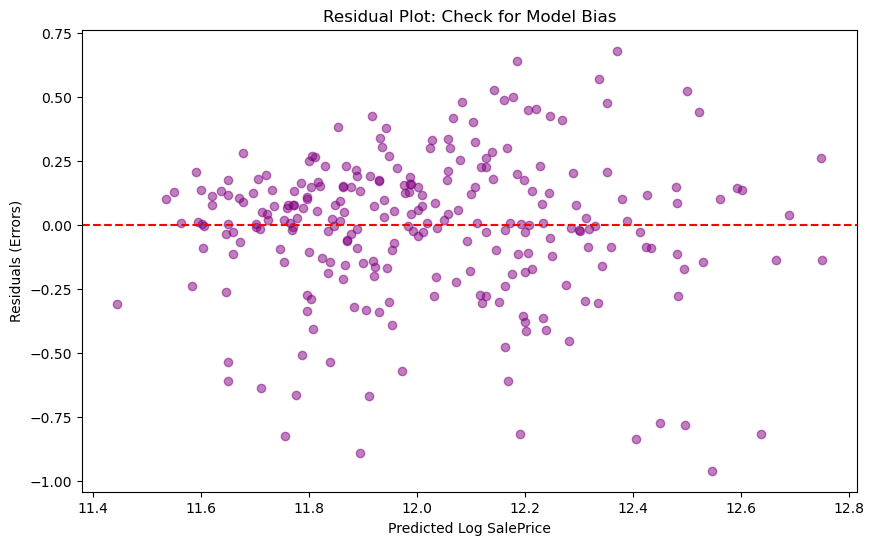

In [36]:
plt.figure(figsize=(10, 6))
residuals = y_val - y_pred

plt.scatter(y_pred, residuals, color='purple', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--') 

plt.title('Residual Plot: Check for Model Bias')
plt.xlabel('Predicted Log SalePrice')
plt.ylabel('Residuals (Errors)')
plt.show()

### Baseline Model Conclusion
Mô hình hồi quy tuyến tính đơn giản sử dụng `GrLivArea` làm biến dự báo duy nhất cho kết quả như sau:
* **RMSE (Actual Price):** $53,161.01
* **R-squared Score:** 0.4601

**Quan sát:**
1. Mô hình giải thích được khoảng **46%** sự biến thiên của giá nhà, xác nhận rằng diện tích sinh hoạt là một biến dự báo mạnh nhưng chưa đủ nếu đứng độc lập.
2. Sai số thặng dư khoảng **~$53k** là tương đối cao, có khả năng do mô hình đã bỏ qua các yếu tố quan trọng khác như chất lượng xây dựng (`OverallQual`), vị trí và tuổi thọ của căn nhà.
3. **Chiến lược cải thiện:** Trong giai đoạn tiếp theo (Mô hình hóa nâng cao), chúng tôi sẽ kết hợp các đầu vào đa biến và các thuật toán phi tuyến tính (như Random Forest hoặc XGBoost) để giảm chỉ số RMSE và nắm bắt 54% sự biến thiên còn lại của giá nhà.